# ControlGen Visualization

This notebook visualizes the current ControlGen schema for both richer SISO and 2x2 MIMO samples.

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import numpy as np


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate repo root from notebook path")


ROOT = find_repo_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

os.environ.setdefault("MPLCONFIGDIR", "/tmp/controlgen-mpl")

import matplotlib.pyplot as plt

from controlgen.generator import DatasetConfig, generate_sample

plt.style.use("seaborn-v0_8-whitegrid")
ROOT

PosixPath('/home/fan/AP/ControlGen')

In [5]:
def load_jsonl_sample(path: Path, index: int = 0) -> dict:
    with path.open("r", encoding="utf-8") as handle:
        for line_no, line in enumerate(handle):
            if line_no == index:
                return json.loads(line)
    raise IndexError(f"Sample index {index} out of range for {path}")


def summarize_sample(sample: dict) -> None:
    system_metrics = sample["metrics"]["system_metrics"]
    print("sample_id:", sample["sample_id"])
    print("system_type:", sample["system_type"], "io_shape:", sample["tags"]["io_shape"])
    print("dsl_text:", sample["dsl_text"])
    print("input_spec:", sample["input_spec"])
    print("tags:", sample["tags"])
    print("system_metrics:")
    for key, value in system_metrics.items():
        if key in {"poles", "zeros", "dc_gain"}:
            continue
        print(f"  {key}: {value}")
    print("channel_metrics:")
    for metrics in sample["metrics"]["channel_metrics"]:
        print(" ", metrics)


def _plot_pole_zero(ax, sample: dict) -> None:
    system_metrics = sample["metrics"]["system_metrics"]
    poles = system_metrics.get("poles", [])
    zeros = system_metrics.get("zeros", [])
    if poles:
        ax.scatter(
            [pole["real"] for pole in poles],
            [pole["imag"] for pole in poles],
            marker="x",
            s=80,
            label="Poles",
        )
    if zeros:
        ax.scatter(
            [zero["real"] for zero in zeros],
            [zero["imag"] for zero in zeros],
            marker="o",
            s=60,
            facecolors="none",
            label="Zeros",
        )
    ax.axhline(0.0, color="black", linewidth=1)
    ax.axvline(0.0, color="black", linewidth=1)
    ax.set_title("Pole / Zero Map")
    ax.set_xlabel("Real")
    ax.set_ylabel("Imag")
    if poles or zeros:
        ax.legend()


def plot_siso_sample(sample: dict) -> None:
    t = np.asarray(sample["t"], dtype=float)
    u = np.asarray(sample["u"], dtype=float)[:, 0]
    y = np.asarray(sample["y"], dtype=float)[:, 0]

    fig_input, ax_input = plt.subplots(figsize=(10, 4.5))
    ax_input.plot(t, u, label="u(t)", linewidth=2)
    ax_input.set_title("SISO Input")
    ax_input.set_xlabel("Time [s]")
    ax_input.set_ylabel("Input")
    ax_input.legend()
    fig_input.suptitle(f"{sample['sample_id']} - Input")
    fig_input.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()

    fig_output, axes_output = plt.subplots(1, 2, figsize=(14, 4.5))
    axes_output[0].plot(t, y, label="y(t)", linewidth=2, color="tab:orange")
    axes_output[0].set_title("SISO Output")
    axes_output[0].set_xlabel("Time [s]")
    axes_output[0].set_ylabel("Output")
    axes_output[0].legend()
    _plot_pole_zero(axes_output[1], sample)
    fig_output.suptitle(f"{sample['sample_id']} - Output")
    fig_output.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()


def plot_mimo_sample(sample: dict) -> None:
    t = np.asarray(sample["t"], dtype=float)
    u = np.asarray(sample["u"], dtype=float)
    y = np.asarray(sample["y"], dtype=float)
    dc_gain = np.asarray(sample["metrics"]["system_metrics"]["dc_gain"], dtype=float)

    fig_input, ax_input = plt.subplots(figsize=(10, 4.5))
    for channel in range(u.shape[1]):
        ax_input.plot(t, u[:, channel], linewidth=2, label=f"u{channel}")
    ax_input.set_title("Input Channels")
    ax_input.set_xlabel("Time [s]")
    ax_input.set_ylabel("Input")
    ax_input.legend()
    fig_input.suptitle(f"{sample['sample_id']} - Input")
    fig_input.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()

    fig_output, axes_output = plt.subplots(1, 2, figsize=(14, 4.5))
    for channel in range(y.shape[1]):
        axes_output[0].plot(t, y[:, channel], linewidth=2, label=f"y{channel}")
    axes_output[0].set_title("Output Channels")
    axes_output[0].set_xlabel("Time [s]")
    axes_output[0].set_ylabel("Output")
    axes_output[0].legend()

    image = axes_output[1].imshow(dc_gain, cmap="coolwarm")
    axes_output[1].set_title("DC Gain Heatmap")
    axes_output[1].set_xlabel("Input Channel")
    axes_output[1].set_ylabel("Output Channel")
    for row in range(dc_gain.shape[0]):
        for col in range(dc_gain.shape[1]):
            axes_output[1].text(
                col,
                row,
                f"{dc_gain[row, col]:.2f}",
                ha="center",
                va="center",
                color="black",
            )
    fig_output.colorbar(image, ax=axes_output[1], fraction=0.046, pad=0.04)
    fig_output.suptitle(f"{sample['sample_id']} - Output")
    fig_output.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()


def plot_sample(sample: dict) -> None:
    if sample["output_channels"] == 1:
        plot_siso_sample(sample)
    else:
        plot_mimo_sample(sample)


## Generate a fresh sample

Switch `system_mode` between `"siso"`, `"mimo"`, and `"mixed"` to inspect different sample families.

sample_id: 202ca6241b10
system_type: control_mimo_2x2 io_shape: 2x2
dsl_text: feedback(forward=series(ss(a=[[-25, -0, 0, 0], [1, 0, 0, 0], [0, 0, -25, -0], [0, 0, 1, 0]], b=[[1, 0], [0, 0], [0, 1], [0, 0]], c=[[-168.68424225, 51.67362139, 0, 0], [0, 0, -406.34669751, 64.69634756]], d=[[7.40966734, 0], [0, 17.29709259]], states=4, inputs=2, outputs=2, name='mimo_controller__diag_pid'), ss(a=[[0, 1.35907797, 0.01357862, 0.53131243], [-2.20557786, -1.73791746, 0.19321497, 0.04249672], [-0.17951018, -0.66073215, 0, 0.86938611], [0.92612998, -0.70659024, -6.86342236, -2.48657597]], b=[[-0.03613042, 0.28227718], [1.03587374, 0.04110412], [0.20098181, 0.22032841], [0.07099548, 0.82459609]], c=[[1, 0, 0.45, 0], [0, 0.45, 1, 0]], d=[[0.017468, 0.02256572], [-0.01540735, 0.01208544]], states=4, inputs=2, outputs=2, name='plant_2x2__strong_coupled')), feedback=matgain(k=[[1, 0], [0, 1]], rows=2, cols=2, name='sensor_2x2'), sign=-1)
input_spec: {'kind': 'step', 'amplitude': 1.5094911478479471, 'fr

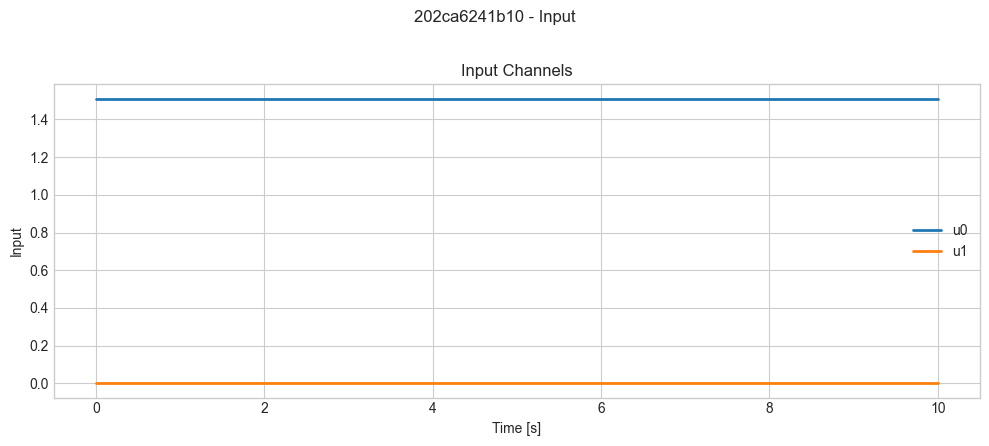

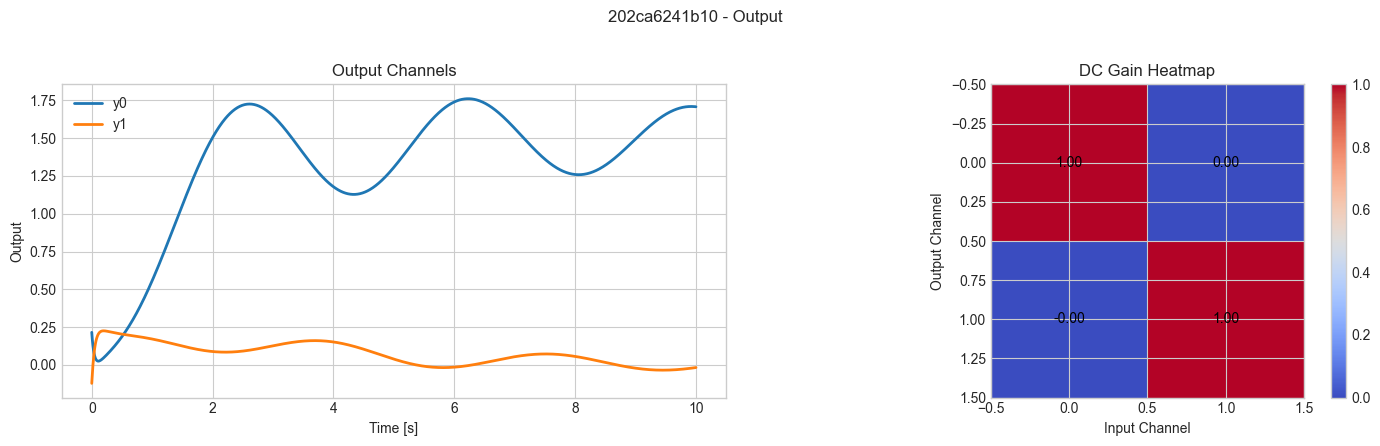

In [15]:
generated = generate_sample(DatasetConfig(seed=222112, count=1, system_mode="mimo"), sample_index=0).to_dict()
summarize_sample(generated)
plot_sample(generated)

## Load a sample from exported JSONL

After exporting data with `python3 -m controlgen.cli --count 100 --system-mode mixed --output artifacts/samples.jsonl`,
set `JSONL_PATH` and `SAMPLE_INDEX` below to inspect a saved row.

In [4]:
JSONL_PATH = ROOT / "artifacts" / "samples.jsonl"
SAMPLE_INDEX = 0

if JSONL_PATH.exists():
    loaded = load_jsonl_sample(JSONL_PATH, index=SAMPLE_INDEX)
    summarize_sample(loaded)
    plot_sample(loaded)
else:
    print(f"No JSONL file found at {JSONL_PATH}")

No JSONL file found at /home/fan/AP/ControlGen/artifacts/samples.jsonl
